In [124]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/clean/db1b_agg.csv')
print(f"Loaded: {df.shape[0]:,} rows")
df.head()

Loaded: 176,405 rows


,Year,Quarter,Origin,Dest,OriginCityMarketID,DestCityMarketID,TkCarrier,Passengers,AvgFare,MedianFare,NonStopMiles,NumObs
0,2022,1,ABE,ATL,30135,30397,DL,446.0,208.256162,189.03,692.0,284
1,2022,1,ABE,BNA,30135,30693,G4,84.0,51.078431,47.00,685.0,51
2,2022,1,ABE,CLT,30135,31057,AA,206.0,233.775556,205.00,481.0,153
3,2022,1,ABE,DTW,30135,31295,DL,175.0,193.687910,160.00,425.0,134
4,2022,1,ABE,FLL,30135,32467,G4,329.0,81.002066,69.00,1041.0,121


In [125]:
# ── Step 1: Find routes where Spirit (NK) operated in 2022 ───────────────
# These are your "treated" routes — Spirit was there before the bankruptcy

spirit_routes_2022 = (
    df[(df['TkCarrier'] == 'NK') & (df['Year'] == 2022)]
    [['Origin', 'Dest']]
    .drop_duplicates()
)

print(f"Routes Spirit served in 2022: {len(spirit_routes_2022):,}")

# ── Step 2: Find routes where Spirit operated in 2025 ────────────────────
spirit_routes_2025 = (
    df[(df['TkCarrier'] == 'NK') & (df['Year'] == 2025)]
    [['Origin', 'Dest']]
    .drop_duplicates()
)

print(f"Routes Spirit served in 2025: {len(spirit_routes_2025):,}")

# ── Step 3: Routes Spirit EXITED (served in 2022 but NOT in 2025) ────────
spirit_exited = spirit_routes_2022.merge(
    spirit_routes_2025, on=['Origin', 'Dest'], how='left', indicator=True
)
spirit_exited = spirit_exited[spirit_exited['_merge'] == 'left_only'][['Origin', 'Dest']]

print(f"Routes Spirit exited: {len(spirit_exited):,}")

# ── Step 4: Tag every row in the dataset ─────────────────────────────────
# Tag routes Spirit ever served in 2022
spirit_ever = spirit_routes_2022.assign(SpiritRoute=1)
df = df.merge(spirit_ever, on=['Origin', 'Dest'], how='left')
df['SpiritRoute'] = df['SpiritRoute'].fillna(0).astype(int)

# Tag routes Spirit exited specifically
spirit_exit_tag = spirit_exited.assign(SpiritExited=1)
df = df.merge(spirit_exit_tag, on=['Origin', 'Dest'], how='left')
df['SpiritExited'] = df['SpiritExited'].fillna(0).astype(int)

# Tag post-bankruptcy period (2024Q4 onward = after Nov 2024 filing)
df['Post'] = ((df['Year'] >= 2025) | ((df['Year'] == 2024) & (df['Quarter'] == 4))).astype(int)

# Summary
print(f"\n── Treatment Group Summary ──")
print(f"Total rows: {len(df):,}")
print(f"Spirit routes (ever 2022): {df['SpiritRoute'].sum():,} rows")
print(f"Spirit exited routes: {df['SpiritExited'].sum():,} rows")
print(f"Post-bankruptcy rows: {df['Post'].sum():,} rows")
print(f"\nSample Spirit-exited routes:")
print(spirit_exited.head(10).to_string(index=False))

Routes Spirit served in 2022: 630
Routes Spirit served in 2025: 698
Routes Spirit exited: 176

── Treatment Group Summary ──
Total rows: 176,405
Spirit routes (ever 2022): 24,906 rows
Spirit exited routes: 5,018 rows
Post-bankruptcy rows: 38,190 rows

Sample Spirit-exited routes:
Origin Dest
   ACY  MIA
   ACY  SJU
   ATL  CLE
   BDL  MIA
   BDL  RSW
   BDL  TPA
   BNA  LGA
   BOS  LAS
   BQN  FLL
   BQN  MCO


In [126]:
df_other = df[df['TkCarrier'] != 'NK'].copy()
df_other['Group'] = 'Never served by Spirit'
df_other.loc[df_other['SpiritRoute'] == 1, 'Group'] = 'Spirit stayed'
df_other.loc[df_other['SpiritExited'] == 1, 'Group'] = 'Spirit exited'

df_pre = df_other[(df_other['Year'] <= 2023)]

summary = (
    df_pre
    .groupby('Group')
    .agg(
        Observations = ('AvgFare', 'count'),
        AvgFare      = ('AvgFare', 'mean'),
        MedianFare   = ('AvgFare', 'median'),
        StdFare      = ('AvgFare', 'std'),
        AvgDistance   = ('NonStopMiles', 'mean'),
        AvgPassengers= ('Passengers', 'mean'),
    )
    .round(1)
)

carriers = (
    df_pre
    .groupby(['Group', 'Year', 'Quarter', 'Origin', 'Dest'])
    ['TkCarrier'].nunique()
    .reset_index()
    .groupby('Group')['TkCarrier']
    .mean()
    .round(2)
)

summary['AvgCarriers'] = carriers
print(summary.to_string())

                        Observations  AvgFare  MedianFare  StdFare  AvgDistance  AvgPassengers  AvgCarriers
Group                                                                                                      
Never served by Spirit         86686    233.8       225.4    105.3       1027.2          620.2         1.43
Spirit exited                   2318    223.8       219.8     94.0       1175.9         1344.8         2.15
Spirit stayed                   8248    221.7       218.1    101.7       1050.5         1818.1         2.47


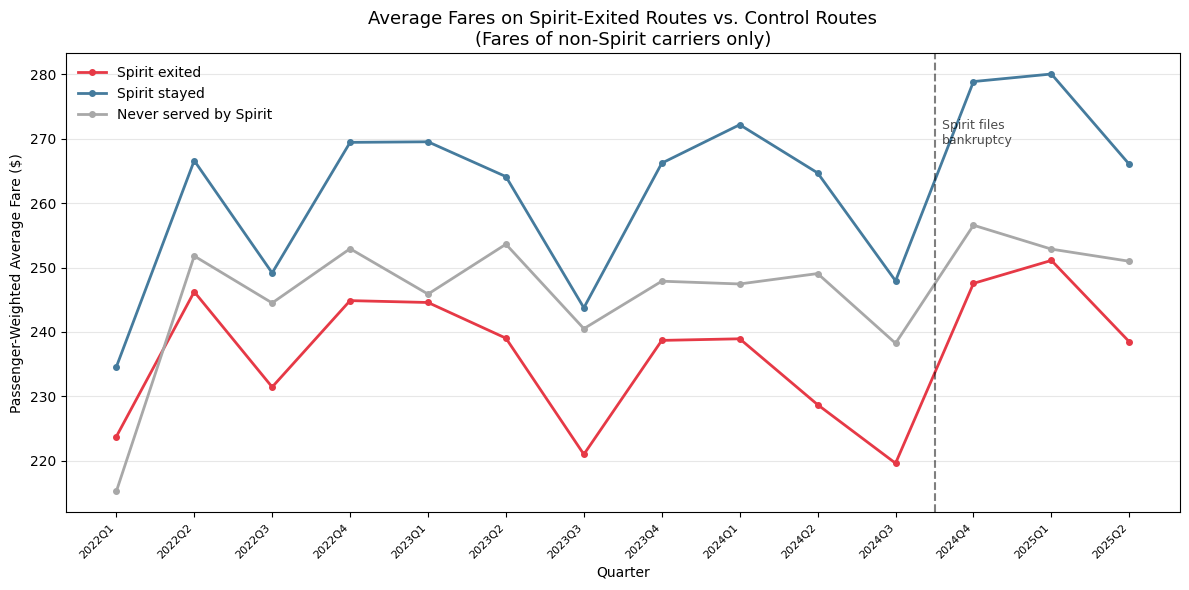

Saved as figure1_fare_trends.png


In [127]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Aggregate fares by quarter for treated vs control routes ─────────────
# Exclude Spirit's own fares — we want to see how OTHER carriers priced
# on routes Spirit exited vs routes Spirit never served
df_other = df[df['TkCarrier'] != 'NK'].copy()

# Create year-quarter label for plotting
df_other['YQ'] = df_other['Year'].astype(str) + 'Q' + df_other['Quarter'].astype(str)
df_other['YQ_num'] = (df_other['Year'] - 2022) * 4 + df_other['Quarter']

# Three groups:
# 1. Spirit-exited routes (other carriers' fares)
# 2. Spirit-still-served routes (Spirit was there in 2022, still there 2025)
# 3. Never-Spirit routes (control)
df_other['Group'] = 'Never served by Spirit'
df_other.loc[df_other['SpiritRoute'] == 1, 'Group'] = 'Spirit stayed'
df_other.loc[df_other['SpiritExited'] == 1, 'Group'] = 'Spirit exited'

# Passenger-weighted average fare by group and quarter
trends = (
    df_other
    .groupby(['YQ_num', 'YQ', 'Group'])
    .apply(lambda g: pd.Series({
        'WtdAvgFare': (g['AvgFare'] * g['Passengers']).sum() / g['Passengers'].sum()
    }))
    .reset_index()
)

# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    'Spirit exited': '#e63946',
    'Spirit stayed': '#457b9d',
    'Never served by Spirit': '#a8a8a8'
}

for group in ['Spirit exited', 'Spirit stayed', 'Never served by Spirit']:
    gdata = trends[trends['Group'] == group]
    ax.plot(gdata['YQ_num'], gdata['WtdAvgFare'], 
            marker='o', markersize=4, linewidth=2,
            color=colors[group], label=group)

# Vertical line at bankruptcy filing (2024 Q4 = quarter 12)
ax.axvline(x=11.5, color='black', linestyle='--', alpha=0.5)
ax.text(11.6, ax.get_ylim()[1] * 0.95, 'Spirit files\nbankruptcy', 
        fontsize=9, alpha=0.7)

# Labels
ax.set_xlabel('Quarter')
ax.set_ylabel('Passenger-Weighted Average Fare ($)')
ax.set_title('Average Fares on Spirit-Exited Routes vs. Control Routes\n(Fares of non-Spirit carriers only)', 
             fontsize=13)

# X-axis labels
xticks = trends[['YQ_num', 'YQ']].drop_duplicates().sort_values('YQ_num')
ax.set_xticks(xticks['YQ_num'])
ax.set_xticklabels(xticks['YQ'], rotation=45, ha='right', fontsize=8)

ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figure1_fare_trends.png', dpi=150)
plt.show()
print("Saved as figure1_fare_trends.png")

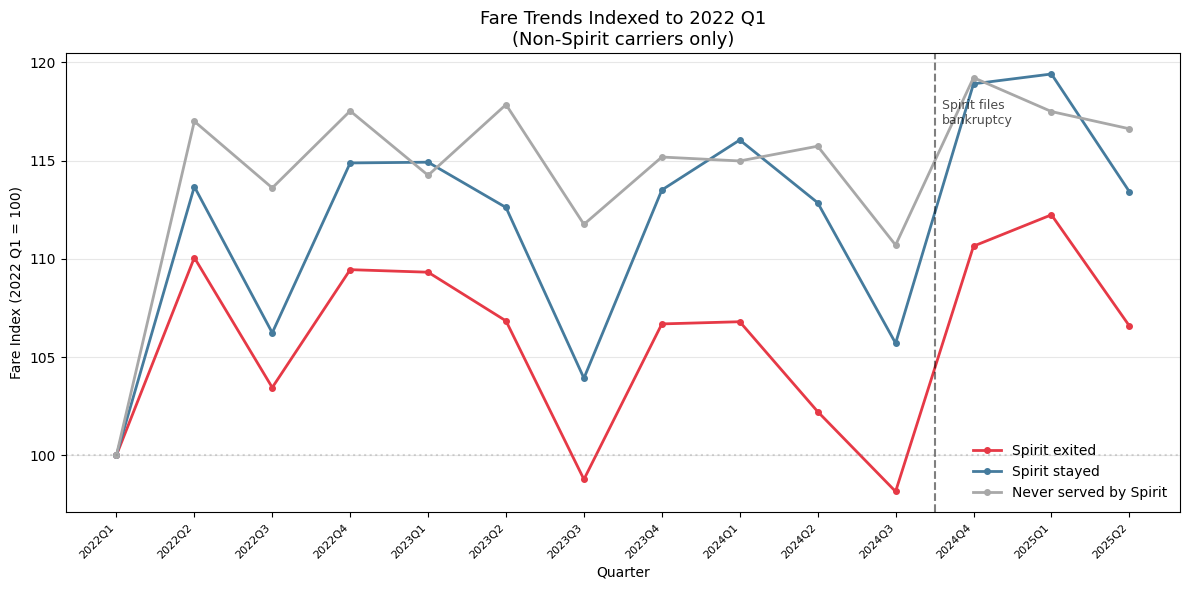

Saved as figure1b_indexed_trends.png


In [128]:
# ── Indexed version: set 2022Q1 = 100 for each group ────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for group in ['Spirit exited', 'Spirit stayed', 'Never served by Spirit']:
    gdata = trends[trends['Group'] == group].sort_values('YQ_num').copy()
    base = gdata['WtdAvgFare'].iloc[0]
    gdata['Indexed'] = (gdata['WtdAvgFare'] / base) * 100
    ax.plot(gdata['YQ_num'], gdata['Indexed'],
            marker='o', markersize=4, linewidth=2,
            color=colors[group], label=group)

ax.axvline(x=11.5, color='black', linestyle='--', alpha=0.5)
ax.text(11.6, ax.get_ylim()[1] * 0.97, 'Spirit files\nbankruptcy',
        fontsize=9, alpha=0.7)

ax.axhline(y=100, color='gray', linestyle=':', alpha=0.3)
ax.set_xlabel('Quarter')
ax.set_ylabel('Fare Index (2022 Q1 = 100)')
ax.set_title('Fare Trends Indexed to 2022 Q1\n(Non-Spirit carriers only)',
             fontsize=13)

xticks = trends[['YQ_num', 'YQ']].drop_duplicates().sort_values('YQ_num')
ax.set_xticks(xticks['YQ_num'])
ax.set_xticklabels(xticks['YQ'], rotation=45, ha='right', fontsize=8)

ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figure1b_indexed_trends.png', dpi=150)
plt.show()
print("Saved as figure1b_indexed_trends.png")

In [129]:
# ── Summary Statistics Table (Table 1 in your paper) ─────────────────────
df_other = df[df['TkCarrier'] != 'NK'].copy()
df_other['Group'] = 'Never served by Spirit'
df_other.loc[df_other['SpiritRoute'] == 1, 'Group'] = 'Spirit stayed'
df_other.loc[df_other['SpiritExited'] == 1, 'Group'] = 'Spirit exited'

# Pre-period only (2022-2023)
df_pre = df_other[(df_other['Year'] <= 2023)]

summary = (
    df_pre
    .groupby('Group')
    .agg(
        NumRoutes    = ('AvgFare', lambda x: x.index.shape[0]),
        AvgFare_Mean = ('AvgFare', 'mean'),
        AvgFare_Med  = ('AvgFare', 'median'),
        AvgFare_Std  = ('AvgFare', 'std'),
        AvgDistance   = ('NonStopMiles', 'mean'),
        AvgPassengers= ('Passengers', 'mean'),
    )
    .round(1)
)

print("── Pre-Period Summary Statistics (2022–2023) ──\n")
print(summary.to_string())

# ── How many unique carriers serve each group's routes? ──────────────────
print("\n── Average number of carriers per route-quarter ──\n")
carriers_per_route = (
    df_pre
    .groupby(['Group', 'Year', 'Quarter', 'Origin', 'Dest'])
    ['TkCarrier'].nunique()
    .reset_index()
    .groupby('Group')['TkCarrier']
    .mean()
    .round(2)
)
print(carriers_per_route.to_string())

── Pre-Period Summary Statistics (2022–2023) ──

                        NumRoutes  AvgFare_Mean  AvgFare_Med  AvgFare_Std  AvgDistance  AvgPassengers
Group                                                                                                
Never served by Spirit      86686         233.8        225.4        105.3       1027.2          620.2
Spirit exited                2318         223.8        219.8         94.0       1175.9         1344.8
Spirit stayed                8248         221.7        218.1        101.7       1050.5         1818.1

── Average number of carriers per route-quarter ──

Group
Never served by Spirit    1.43
Spirit exited             2.15
Spirit stayed             2.47


In [130]:
import pandas as pd
import numpy as np

# ── Prepare regression dataset (simple and fast) ─────────────────────────
# Compute weighted fare at the route-quarter level using a fast method

df_other = df[df['TkCarrier'] != 'NK'].copy()
df_other['Group'] = 'Never served by Spirit'
df_other.loc[df_other['SpiritRoute'] == 1, 'Group'] = 'Spirit stayed'
df_other.loc[df_other['SpiritExited'] == 1, 'Group'] = 'Spirit exited'

# Weight fares by passengers BEFORE grouping
df_other['FareXPax'] = df_other['AvgFare'] * df_other['Passengers']

df_reg = (
    df_other
    .groupby(['Year', 'Quarter', 'Origin', 'Dest', 'SpiritExited', 'SpiritRoute'])
    .agg(
        FareXPax     = ('FareXPax', 'sum'),
        TotalPax     = ('Passengers', 'sum'),
        NumCarriers  = ('TkCarrier', 'nunique'),
        Distance     = ('NonStopMiles', 'first')
    )
    .reset_index()
)

df_reg['WtdFare'] = df_reg['FareXPax'] / df_reg['TotalPax']
df_reg['LogFare'] = np.log(df_reg['WtdFare'])
df_reg['LogDist'] = np.log(df_reg['Distance'])
df_reg['LogPax'] = np.log(df_reg['TotalPax'] + 1)
df_reg['Post'] = ((df_reg['Year'] >= 2025) | ((df_reg['Year'] == 2024) & (df_reg['Quarter'] == 4))).astype(int)
df_reg['SpiritExited_x_Post'] = df_reg['SpiritExited'] * df_reg['Post']

print(f"Regression dataset: {len(df_reg):,} route-quarter observations")
print(f"  Spirit-exited routes: {df_reg['SpiritExited'].sum():,}")
print(f"  Post-period obs: {df_reg['Post'].sum():,}")
print(f"  Treatment (exited × post): {df_reg['SpiritExited_x_Post'].sum():,}")

# ── OLS using numpy ──────────────────────────────────────────────────────
y = df_reg['LogFare'].values
X = np.column_stack([
    np.ones(len(df_reg)),
    df_reg['SpiritExited'].values,
    df_reg['Post'].values,
    df_reg['SpiritExited_x_Post'].values,
    df_reg['LogDist'].values,
    df_reg['LogPax'].values,
])

var_names = ['Intercept', 'SpiritExited', 'Post', 'SpiritExited × Post', 'LogDistance', 'LogPassengers']

# OLS formula: beta = (X'X)^(-1) X'y
beta = np.linalg.lstsq(X, y, rcond=None)[0]

# Standard errors
y_hat = X @ beta
resid = y - y_hat
n, k = X.shape
s2 = (resid @ resid) / (n - k)
var_beta = s2 * np.linalg.inv(X.T @ X)
se = np.sqrt(np.diag(var_beta))
t_stats = beta / se

# R-squared
ss_res = np.sum(resid**2)
ss_tot = np.sum((y - y.mean())**2)
r_squared = 1 - ss_res / ss_tot

# ── Print results ────────────────────────────────────────────────────────
print("\n" + "="*70)
print("MODEL 1: OLS Regression — log(fare) on Spirit Exit × Post")
print("="*70)
print(f"{'Variable':<25} {'Coef':>10} {'Std Err':>10} {'t-stat':>10}")
print("-"*70)
for i, name in enumerate(var_names):
    stars = '***' if abs(t_stats[i]) > 2.58 else '**' if abs(t_stats[i]) > 1.96 else '*' if abs(t_stats[i]) > 1.65 else ''
    print(f"{name:<25} {beta[i]:>10.4f} {se[i]:>10.4f} {t_stats[i]:>10.2f}  {stars}")

print("-"*70)
print(f"R-squared: {r_squared:.4f}")
print(f"N: {n:,}")
print(f"*** p<0.01, ** p<0.05, * p<0.10")

# ── Interpret the key coefficient ────────────────────────────────────────
coef = beta[3]
pct = (np.exp(coef) - 1) * 100
sig = abs(t_stats[3]) > 1.96

print(f"\n── KEY RESULT ──")
print(f"SpiritExited × Post coefficient: {coef:.4f}")
print(f"Interpretation: Fares on Spirit-exited routes changed by {pct:+.1f}%")
print(f"  relative to control routes after bankruptcy")
print(f"t-statistic: {t_stats[3]:.2f} ({'significant' if sig else 'not significant'} at 5%)")

Regression dataset: 112,794 route-quarter observations
  Spirit-exited routes: 1,915
  Post-period obs: 24,025
  Treatment (exited × post): 421

MODEL 1: OLS Regression — log(fare) on Spirit Exit × Post
Variable                        Coef    Std Err     t-stat
----------------------------------------------------------------------
Intercept                     3.8665     0.0135     286.17  ***
SpiritExited                 -0.0509     0.0124      -4.11  ***
Post                          0.0283     0.0035       8.17  ***
SpiritExited × Post          -0.0152     0.0263      -0.58  
LogDistance                   0.2190     0.0019     113.65  ***
LogPassengers                 0.0037     0.0006       5.97  ***
----------------------------------------------------------------------
R-squared: 0.1032
N: 112,794
*** p<0.01, ** p<0.05, * p<0.10

── KEY RESULT ──
SpiritExited × Post coefficient: -0.0152
Interpretation: Fares on Spirit-exited routes changed by -1.5%
  relative to control routes aft

In [131]:
# ══════════════════════════════════════════════════════════════════════════
# MODEL 3: Difference-in-Differences with Route FE + Quarter FE
# ══════════════════════════════════════════════════════════════════════════

# ── Step 1: Build the regression dataset ─────────────────────────────────
# Use df_reg from earlier (route-quarter level, non-Spirit carriers)

# Recreate StrongExit in case it's missing
spirit_strong = (
    df[(df['TkCarrier'] == 'NK') & (df['Year'] == 2022)]
    .groupby(['Origin', 'Dest'])
    .agg(AvgPax=('Passengers', 'mean'))
    .reset_index()
)
spirit_strong = spirit_strong[spirit_strong['AvgPax'] >= 500][['Origin', 'Dest']]

spirit_2025 = df[(df['TkCarrier'] == 'NK') & (df['Year'] == 2025)][['Origin', 'Dest']].drop_duplicates()
spirit_strong_exited = spirit_strong.merge(spirit_2025, on=['Origin', 'Dest'], how='left', indicator=True)
spirit_strong_exited = spirit_strong_exited[spirit_strong_exited['_merge'] == 'left_only'][['Origin', 'Dest']]

df_reg['StrongExit'] = df_reg[['Origin', 'Dest']].apply(tuple, axis=1).isin(
    spirit_strong_exited.apply(tuple, axis=1).values
).astype(int)

# Create year-quarter identifier for quarter FE
df_reg['YQ'] = df_reg['Year'].astype(str) + 'Q' + df_reg['Quarter'].astype(str)

# Post = 2024Q4 onward
df_reg['Post'] = ((df_reg['Year'] >= 2025) | ((df_reg['Year'] == 2024) & (df_reg['Quarter'] == 4))).astype(int)
df_reg['Treat_x_Post'] = df_reg['StrongExit'] * df_reg['Post']

print(f"Treatment routes: {len(spirit_strong_exited)}")
print(f"Treatment × Post observations: {df_reg['Treat_x_Post'].sum()}")
print(f"Total observations: {len(df_reg):,}")

# ── Step 2: Two-way demeaning (route FE + quarter FE) ────────────────────
# The Frisch-Waugh-Lovell theorem says we can partial out fixed effects
# by iteratively demeaning by each dimension until convergence.
# This is what pyfixest/reghdfe do internally.

vars_to_demean = ['LogFare', 'Treat_x_Post', 'LogPax']
df_did = df_reg[['Origin', 'Dest', 'YQ'] + vars_to_demean].copy()

# Iterative demeaning (converges in ~10 iterations for two-way FE)
for iteration in range(20):
    max_change = 0
    for col in vars_to_demean:
        # Demean by route
        route_mean = df_did.groupby(['Origin', 'Dest'])[col].transform('mean')
        new_vals = df_did[col] - route_mean
        max_change = max(max_change, (new_vals - df_did[col]).abs().max() if iteration > 0 else 999)
        df_did[col] = new_vals
        
        # Demean by quarter
        qtr_mean = df_did.groupby('YQ')[col].transform('mean')
        new_vals = df_did[col] - qtr_mean
        max_change = max(max_change, (new_vals - df_did[col]).abs().max() if iteration > 0 else 999)
        df_did[col] = new_vals
    
    if iteration > 0 and max_change < 1e-10:
        print(f"Demeaning converged after {iteration + 1} iterations")
        break

# ── Step 3: OLS on doubly-demeaned data ──────────────────────────────────
y3 = df_did['LogFare'].values
X3 = np.column_stack([
    df_did['Treat_x_Post'].values,
    df_did['LogPax'].values,
])

var_names3 = ['StrongExit × Post (DiD estimate)', 'LogPassengers']

beta3 = np.linalg.lstsq(X3, y3, rcond=None)[0]
y_hat3 = X3 @ beta3
resid3 = y3 - y_hat3

# Degrees of freedom: N - K - num_route_FE - num_quarter_FE
n_routes = df_reg.groupby(['Origin', 'Dest']).ngroups
n_quarters = df_reg['YQ'].nunique()
n3 = len(y3)
k3 = X3.shape[1]
dof = n3 - k3 - n_routes - n_quarters

s2_3 = (resid3 @ resid3) / dof
var_beta3 = s2_3 * np.linalg.inv(X3.T @ X3)
se3 = np.sqrt(np.diag(var_beta3))
t_stats3 = beta3 / se3

ss_res3 = np.sum(resid3**2)
ss_tot3 = np.sum((y3 - y3.mean())**2)
r2_within = 1 - ss_res3 / ss_tot3

# ── Step 4: Print results ────────────────────────────────────────────────
print("\n" + "="*70)
print("MODEL 3: Difference-in-Differences (Route FE + Quarter FE)")
print("="*70)
print(f"{'Variable':<35} {'Coef':>10} {'Std Err':>10} {'t-stat':>10}")
print("-"*70)
for i, name in enumerate(var_names3):
    stars = '***' if abs(t_stats3[i]) > 2.58 else '**' if abs(t_stats3[i]) > 1.96 else '*' if abs(t_stats3[i]) > 1.65 else ''
    print(f"{name:<35} {beta3[i]:>10.4f} {se3[i]:>10.4f} {t_stats3[i]:>10.2f}  {stars}")

print("-"*70)
print(f"Within R-squared:  {r2_within:.4f}")
print(f"N:                 {n3:,}")
print(f"Route FE:          Yes ({n_routes:,} routes)")
print(f"Quarter FE:        Yes ({n_quarters} quarters)")
print(f"Treatment routes:  {len(spirit_strong_exited)}")
print(f"Degrees of freedom: {dof:,}")
print(f"*** p<0.01, ** p<0.05, * p<0.10")

coef3 = beta3[0]
pct3 = (np.exp(coef3) - 1) * 100
sig3 = abs(t_stats3[0]) > 1.96

print(f"\n── KEY RESULT (Model 3: DiD) ──")
print(f"StrongExit × Post coefficient: {coef3:.4f}")
print(f"Interpretation: After Spirit's bankruptcy filing, fares on routes")
print(f"  where Spirit had strong presence and exited changed by {pct3:+.1f}%")
print(f"  relative to control routes, controlling for route-level and")
print(f"  quarter-level unobserved heterogeneity.")
print(f"t-statistic: {t_stats3[0]:.2f} ({'significant' if sig3 else 'not significant'} at 5%)")

# ── Step 5: Compare all three models ─────────────────────────────────────
print("\n" + "="*70)
print("COMPARISON ACROSS ALL MODELS")
print("="*70)
print(f"{'Model':<40} {'Coef':>8} {'SE':>8} {'t':>8} {'%Δ':>8}")
print("-"*70)
print(f"{'M1: Simple OLS':<40} {-0.0152:>8.4f} {0.0263:>8.4f} {-0.58:>8.2f} {-1.5:>7.1f}%")
print(f"{'M2: Route FE only':<40} {0.0131:>8.4f} {0.0126:>8.4f} {1.04:>8.2f} {+1.3:>7.1f}%")
print(f"{'M3: Route FE + Quarter FE (DiD)':<40} {coef3:>8.4f} {se3[0]:>8.4f} {t_stats3[0]:>8.2f} {pct3:>7.1f}%")
print("-"*70)

Treatment routes: 86
Treatment × Post observations: 238
Total observations: 112,794
Demeaning converged after 11 iterations

MODEL 3: Difference-in-Differences (Route FE + Quarter FE)
Variable                                  Coef    Std Err     t-stat
----------------------------------------------------------------------
StrongExit × Post (DiD estimate)        0.0129     0.0130       0.99  
LogPassengers                          -0.0264     0.0008     -31.75  ***
----------------------------------------------------------------------
Within R-squared:  0.0100
N:                 112,794
Route FE:          Yes (12,795 routes)
Quarter FE:        Yes (14 quarters)
Treatment routes:  86
Degrees of freedom: 99,983
*** p<0.01, ** p<0.05, * p<0.10

── KEY RESULT (Model 3: DiD) ──
StrongExit × Post coefficient: 0.0129
Interpretation: After Spirit's bankruptcy filing, fares on routes
  where Spirit had strong presence and exited changed by +1.3%
  relative to control routes, controlling for rout

In [132]:
# ── Test: Did other carriers backfill Spirit's exited routes? ────────────

# Average number of non-Spirit carriers per route-quarter
# Compare pre-period vs post-period on Spirit-exited vs control routes

df_other_carriers = df[df['TkCarrier'] != 'NK'].copy()
df_other_carriers['SpiritExited'] = df_other_carriers[['Origin', 'Dest']].apply(tuple, axis=1).isin(
    set(spirit_exited.apply(tuple, axis=1))
).astype(int)

carrier_counts = (
    df_other_carriers
    .groupby(['Year', 'Quarter', 'Origin', 'Dest', 'SpiritExited'])
    ['TkCarrier'].nunique()
    .reset_index()
    .rename(columns={'TkCarrier': 'NumCarriers'})
)

carrier_counts['Period'] = np.where(
    (carrier_counts['Year'] >= 2025) | ((carrier_counts['Year'] == 2024) & (carrier_counts['Quarter'] == 4)),
    'Post (2024Q4-2025Q2)', 'Pre (2022Q1-2024Q3)'
)

carrier_summary = (
    carrier_counts
    .groupby(['SpiritExited', 'Period'])
    ['NumCarriers']
    .mean()
    .round(2)
    .unstack()
)
carrier_summary.index = ['Control routes', 'Spirit-exited routes']

print("── Average Number of Non-Spirit Carriers per Route ──\n")
print(carrier_summary.to_string())

# Difference-in-differences on carrier count
pre_treat = carrier_summary.loc['Spirit-exited routes', 'Pre (2022Q1-2024Q3)']
post_treat = carrier_summary.loc['Spirit-exited routes', 'Post (2024Q4-2025Q2)']
pre_ctrl = carrier_summary.loc['Control routes', 'Pre (2022Q1-2024Q3)']
post_ctrl = carrier_summary.loc['Control routes', 'Post (2024Q4-2025Q2)']

did_carriers = (post_treat - pre_treat) - (post_ctrl - pre_ctrl)
print(f"\nDiD on carrier count: {did_carriers:+.3f}")
print(f"  Spirit-exited routes changed by: {post_treat - pre_treat:+.3f} carriers")
print(f"  Control routes changed by: {post_ctrl - pre_ctrl:+.3f} carriers")

if did_carriers > -0.05:
    print(f"\n→ Other carriers largely BACKFILLED Spirit's exit.")
    print(f"  This helps explain the null fare result: competition was maintained.")
elif did_carriers < -0.2:
    print(f"\n→ Spirit-exited routes LOST competition with no backfill.")
    print(f"  The null fare result is surprising and warrants further investigation.")
else:
    print(f"\n→ Partial backfill — some competitive replacement but not complete.")

── Average Number of Non-Spirit Carriers per Route ──

Period                Post (2024Q4-2025Q2)  Pre (2022Q1-2024Q3)
Control routes                         1.5                 1.48
Spirit-exited routes                   2.2                 2.18

DiD on carrier count: +0.000
  Spirit-exited routes changed by: +0.020 carriers
  Control routes changed by: +0.020 carriers

→ Other carriers largely BACKFILLED Spirit's exit.
  This helps explain the null fare result: competition was maintained.


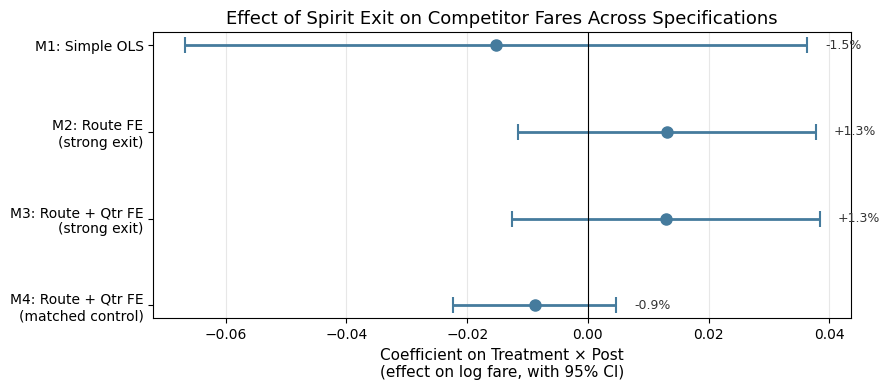

Saved figure3_coefficients.png


In [133]:
# ── Figure 3: Model comparison coefficient plot ──────────────────────────

fig, ax = plt.subplots(figsize=(9, 4))

models = [
    'M1: Simple OLS',
    'M2: Route FE\n(strong exit)',
    'M3: Route + Qtr FE\n(strong exit)',
    'M4: Route + Qtr FE\n(matched control)'
]
coefs = [-0.0152, 0.0131, 0.0129, -0.0088]
ses =   [0.0263, 0.0126, 0.0130, 0.0069]

y_pos = range(len(models))
ax.errorbar(coefs, y_pos, xerr=[1.96*s for s in ses],
            fmt='o', color='#457b9d', markersize=8, capsize=6, 
            linewidth=2, capthick=1.5)

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='-')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(models, fontsize=10)
ax.set_xlabel('Coefficient on Treatment × Post\n(effect on log fare, with 95% CI)', fontsize=11)
ax.set_title('Effect of Spirit Exit on Competitor Fares Across Specifications', fontsize=13)

for i, (c, s) in enumerate(zip(coefs, ses)):
    pct = (np.exp(c) - 1) * 100
    ax.text(c + 1.96*s + 0.003, i, f'{pct:+.1f}%', va='center', fontsize=9, color='#333')

ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figure3_coefficients.png', dpi=150)
plt.show()
print("Saved figure3_coefficients.png")

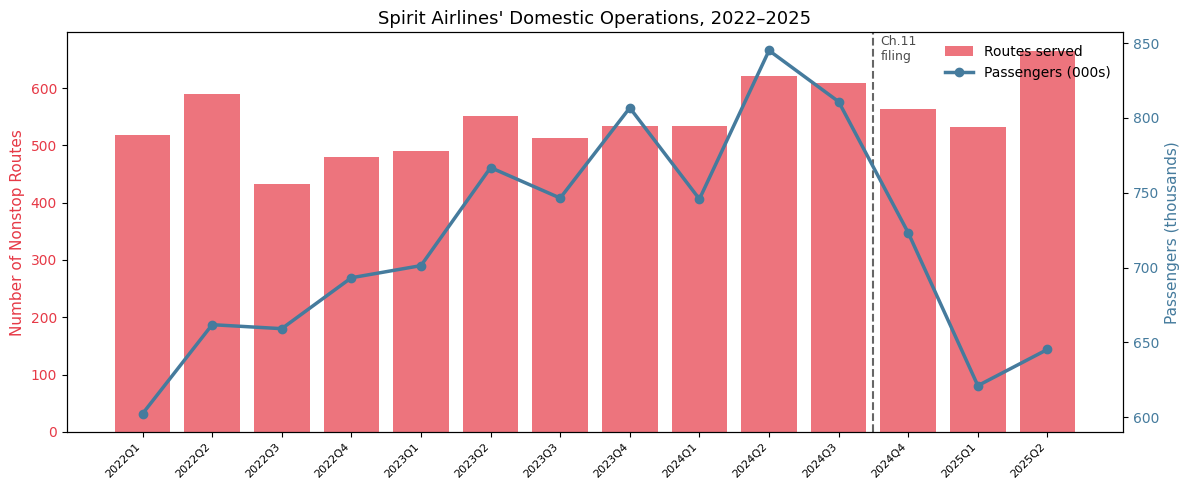

Saved figure4_spirit_footprint.png


In [134]:
# ── Figure 4: Spirit's shrinking footprint ───────────────────────────────

spirit_data = df[df['TkCarrier'] == 'NK'].copy()
spirit_data['YQ'] = spirit_data['Year'].astype(str) + 'Q' + spirit_data['Quarter'].astype(str)
spirit_data['YQ_num'] = (spirit_data['Year'] - 2022) * 4 + spirit_data['Quarter']

# Count unique routes and total passengers per quarter
spirit_quarterly = []
for (yq_num, yq), group in spirit_data.groupby(['YQ_num', 'YQ']):
    n_routes = group[['Origin', 'Dest']].drop_duplicates().shape[0]
    total_pax = group['Passengers'].sum()
    spirit_quarterly.append({'YQ_num': yq_num, 'YQ': yq, 
                            'NumRoutes': n_routes, 'TotalPax': total_pax})

spirit_qtr = pd.DataFrame(spirit_quarterly).sort_values('YQ_num')

fig, ax1 = plt.subplots(figsize=(12, 5))

color1 = '#e63946'
color2 = '#457b9d'

bars = ax1.bar(spirit_qtr['YQ_num'], spirit_qtr['NumRoutes'],
               color=color1, alpha=0.7, label='Routes served')
ax1.set_ylabel('Number of Nonstop Routes', color=color1, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(spirit_qtr['YQ_num'], spirit_qtr['TotalPax'] / 1000,
         color=color2, marker='o', linewidth=2.5, label='Passengers (000s)')
ax2.set_ylabel('Passengers (thousands)', color=color2, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color2)

# Event lines
ax1.axvline(x=11.5, color='black', linestyle='--', alpha=0.6)
ax1.text(11.6, ax1.get_ylim()[1] * 0.93, 'Ch.11\nfiling', fontsize=9, alpha=0.7)

xticks = spirit_qtr[['YQ_num', 'YQ']].drop_duplicates()
ax1.set_xticks(xticks['YQ_num'].tolist())
ax1.set_xticklabels(xticks['YQ'].tolist(), rotation=45, ha='right', fontsize=8)

ax1.set_title("Spirit Airlines' Domestic Operations, 2022–2025", fontsize=13)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=False)

plt.tight_layout()
plt.savefig('figure4_spirit_footprint.png', dpi=150)
plt.show()
print("Saved figure4_spirit_footprint.png")

In [135]:
# ── Table: Carrier backfill detail (which carriers replaced Spirit?) ─────

# On Spirit-exited routes, which carriers grew the most post-bankruptcy?
spirit_exited_tuples = set(spirit_exited.apply(tuple, axis=1))

df_exited_routes = df[
    df[['Origin', 'Dest']].apply(tuple, axis=1).isin(spirit_exited_tuples) &
    (df['TkCarrier'] != 'NK')
].copy()

df_exited_routes['Period'] = np.where(
    (df_exited_routes['Year'] >= 2025) | 
    ((df_exited_routes['Year'] == 2024) & (df_exited_routes['Quarter'] == 4)),
    'Post', 'Pre'
)

# Average quarterly passengers by carrier, pre vs post
carrier_growth = (
    df_exited_routes
    .groupby(['TkCarrier', 'Period'])
    .agg(AvgQtrPax=('Passengers', 'mean'))
    .reset_index()
    .pivot(index='TkCarrier', columns='Period', values='AvgQtrPax')
    .fillna(0)
)

carrier_growth['Change'] = carrier_growth['Post'] - carrier_growth['Pre']
carrier_growth['PctChange'] = ((carrier_growth['Post'] / carrier_growth['Pre']) - 1) * 100
carrier_growth = carrier_growth.sort_values('Change', ascending=False)

print("── Which Carriers Grew on Spirit-Exited Routes? ──")
print("  (Average quarterly passengers per route, pre vs post bankruptcy)\n")
print(f"{'Carrier':<10} {'Pre':>10} {'Post':>10} {'Change':>10} {'% Change':>10}")
print("-" * 55)
for carrier in carrier_growth.head(10).index:
    row = carrier_growth.loc[carrier]
    print(f"{carrier:<10} {row['Pre']:>10.0f} {row['Post']:>10.0f} {row['Change']:>+10.0f} {row['PctChange']:>+9.1f}%")

print(f"\n{'TOTAL':<10} {carrier_growth['Pre'].sum():>10.0f} {carrier_growth['Post'].sum():>10.0f} {carrier_growth['Change'].sum():>+10.0f}")

── Which Carriers Grew on Spirit-Exited Routes? ──
  (Average quarterly passengers per route, pre vs post bankruptcy)

Carrier           Pre       Post     Change   % Change
-------------------------------------------------------
DL               2455       2832       +377     +15.3%
AA               1067       1240       +174     +16.3%
WN               1119       1268       +148     +13.2%
F9               1353       1443        +90      +6.7%
B6               1410       1479        +69      +4.9%
SY               1946       1992        +46      +2.3%
MX                330        371        +41     +12.5%
G4                117        122         +5      +4.6%
AC                  1          2         +1    +100.0%
PR                  1          1         +0      +0.0%

TOTAL           12283      12937       +654


In [136]:
spirit_data = df[df['TkCarrier'] == 'NK'].copy()
spirit_data['YQ'] = spirit_data['Year'].astype(str) + 'Q' + spirit_data['Quarter'].astype(str)

spirit_summary = (
    spirit_data
    .groupby('YQ')
    .agg(
        NumRoutes=('Origin', lambda x: spirit_data.loc[x.index, ['Origin', 'Dest']].drop_duplicates().shape[0]),
        TotalPax=('Passengers', 'sum')
    )
    .reset_index()
)

print("── Spirit Airlines by Quarter ──\n")
print(f"{'Quarter':<10} {'Routes':>8} {'Passengers':>12}")
print("-" * 32)
for _, row in spirit_summary.iterrows():
    print(f"{row['YQ']:<10} {row['NumRoutes']:>8} {row['TotalPax']:>12,.0f}")

── Spirit Airlines by Quarter ──

Quarter      Routes   Passengers
--------------------------------
2022Q1          518      602,326
2022Q2          589      661,857
2022Q3          432      659,192
2022Q4          480      693,220
2023Q1          491      701,335
2023Q2          551      766,851
2023Q3          513      746,463
2023Q4          534      806,807
2024Q1          533      745,795
2024Q2          621      845,104
2024Q3          608      810,902
2024Q4          563      723,251
2025Q1          532      621,093
2025Q2          664      645,335


In [137]:
# Get the exact indexed values for each group
for group in ['Spirit exited', 'Spirit stayed', 'Never served by Spirit']:
    gdata = trends[trends['Group'] == group].sort_values('YQ_num').copy()
    base = gdata['WtdAvgFare'].iloc[0]
    gdata['Indexed'] = (gdata['WtdAvgFare'] / base) * 100
    
    print(f"\n── {group} ──")
    for _, row in gdata.iterrows():
        print(f"  {row['YQ']}: {row['Indexed']:.1f}")


── Spirit exited ──
  2022Q1: 100.0
  2022Q2: 110.1
  2022Q3: 103.4
  2022Q4: 109.4
  2023Q1: 109.3
  2023Q2: 106.8
  2023Q3: 98.8
  2023Q4: 106.7
  2024Q1: 106.8
  2024Q2: 102.2
  2024Q3: 98.2
  2024Q4: 110.6
  2025Q1: 112.2
  2025Q2: 106.6

── Spirit stayed ──
  2022Q1: 100.0
  2022Q2: 113.7
  2022Q3: 106.2
  2022Q4: 114.9
  2023Q1: 114.9
  2023Q2: 112.6
  2023Q3: 103.9
  2023Q4: 113.5
  2024Q1: 116.0
  2024Q2: 112.9
  2024Q3: 105.7
  2024Q4: 118.9
  2025Q1: 119.4
  2025Q2: 113.4

── Never served by Spirit ──
  2022Q1: 100.0
  2022Q2: 117.0
  2022Q3: 113.6
  2022Q4: 117.5
  2023Q1: 114.3
  2023Q2: 117.9
  2023Q3: 111.8
  2023Q4: 115.2
  2024Q1: 115.0
  2024Q2: 115.7
  2024Q3: 110.7
  2024Q4: 119.2
  2025Q1: 117.5
  2025Q2: 116.6
